# 🚇 팀 B — 서울 지하철 분석 프로젝트
## Week 1: 데이터 수집·정리·1차 탐색 (20점)

---

### 팀 정보

_**아래 표를 채운 후 시작하세요.**_

| 역할 | 이름 | 학번 | 이번 주 담당 |
|---|---|---|---|
| 분석가 A | 윤수빈 | _____ | _____ |
| 분석가 B | 강나영 | _____ | _____ |
| 시각화/디자인 C | 김시현 | _____ | _____ |

---

## 📖 시나리오

당신의 팀은 **서울교통공사 운영전략실**에 컨설팅을 의뢰받았다.

> *"승객 안전과 서비스 품질 향상을 위해, 어느 역이 출퇴근 시간에 가장 혼잡한지, 어떤 호선이 통근 부담이 큰지 데이터로 분석해 달라."*

이 분석을 통해 서울교통공사는 **혼잡 핫스팟 역**을 식별하고, 인력·열차 배차·시설 개선 우선순위를 결정한다.

**3주에 걸쳐 검증할 가설:**
1. 출퇴근 시간(7-9시, 18-20시)의 혼잡이 특정 역·호선에 집중되는가?
2. 승차 핫스팟(주거 중심)과 하차 핫스팟(업무 중심)이 공간적으로 명확히 구분되는가?
3. 호선별로 통근 부담 패턴이 어떻게 다른가?

---

## 📥 데이터 다운로드 안내

**1차 데이터 (이번 주):** 서울시 지하철 호선별 역별 시간대별 승하차 인원 정보
- 링크: https://data.seoul.go.kr/dataList/OA-12252/S/1/datasetView.do
- 형식: CSV
- **추천 기간:** 가장 최근 한 달 또는 분기
- 형식 안내: 한 행이 (사용월, 호선명, 지하철역)이고, 시간대별 승차/하차 인원이 **여러 컬럼으로 가로로 나열**되어 있음 (이를 "wide format"이라 함)

**2차 데이터 (Week 2에서 사용):** 서울시 역사마스터 정보 또는 호선별 부가 정보
- 서울 열린데이터광장에서 "지하철 역사 마스터" 또는 "호선마스터" 검색

_(데이터를 다운받아 노트북과 같은 폴더에 두세요.)_

---

## 🎯 Week 1 목표

이번 주에 다음을 완성합니다:
1. 데이터 로딩과 wide format 구조 파악
2. 결측치·자료형 정리
3. **시간대 컬럼들을 분석에 적합한 형태로 재구성**
4. **`사용월` datetime 처리** + 파생 변수
5. 시간대·호선·역별 이용 패턴 1차 탐색
6. 출퇴근 혼잡 핫스팟 가설 1차 검증
7. 전처리 결과 저장 (Week 2 사용)

**중요:** 코드의 구체적 작성 방식은 팀이 직접 결정하세요. 본 노트북은 *무엇을 할지*만 안내합니다.

---
## ⚙️ 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

---
## Q1. 데이터 로드 및 구조 파악 (3점)

**과제:**
- (a) 다운받은 지하철 시간대별 데이터 CSV를 `subway` 변수에 불러오기
  - ⚠️ **중요**: 이 데이터는 **CP949 인코딩**입니다. UTF-8(기본값)으로 읽으면 한글이 깨집니다.
  - `pd.read_csv(파일경로, encoding="cp949")` 옵션을 사용하세요
- (b) 데이터의 행/열 수, 컬럼명, 자료형 확인
- (c) **컬럼 구조 정리** (markdown):
  - 식별자 역할 컬럼은 무엇인가? (예: 사용월, 호선명, 지하철역)
  - 측정값 컬럼은 무엇인가? (시간대별 승차/하차 인원)
  - 시간대 컬럼이 총 몇 개인가? (예상: 24시간 × 2(승/하차) = 48개)

**예상 결과:**
- 약 50개 컬럼 (식별자 3-4개 + 시간대 48개 + 작업일자 1개)
- 한 행 = (사용월, 호선, 역) 조합 한 개
- 컬럼 예시: `사용월`, `호선명`, `지하철역`, `04시-05시 승차인원`, `04시-05시 하차인원`, ... `작업일자`


In [2]:
# (a) 데이터 로드
subway = pd.read_csv('subway.csv',encoding="cp949")
subway.head()

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자
0,202604,1호선,동대문,699,14,10785,1967,9753,7375,17418,...,10780,1041,3359,1,337,0,0,0,0,20260503
1,202604,1호선,동묘앞,203,10,3112,914,4394,6211,9605,...,5191,156,2421,0,332,0,0,0,0,20260503
2,202604,1호선,서울역,714,53,11801,11865,39975,72460,124120,...,38093,4653,8780,23,247,0,0,0,0,20260503
3,202604,1호선,시청,175,0,1917,6324,4110,33548,8007,...,3798,688,942,3,18,0,0,0,0,20260503
4,202604,1호선,신설동,484,18,8846,2389,11861,10029,25480,...,10208,577,3008,2,2,0,0,0,0,20260503


In [3]:
# (b) 구조 확인
subway.info()

<class 'pandas.DataFrame'>
RangeIndex: 81732 entries, 0 to 81731
Data columns (total 52 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   사용월           81732 non-null  int64
 1   호선명           81732 non-null  str  
 2   지하철역          81732 non-null  str  
 3   04시-05시 승차인원  81732 non-null  int64
 4   04시-05시 하차인원  81732 non-null  int64
 5   05시-06시 승차인원  81732 non-null  int64
 6   05시-06시 하차인원  81732 non-null  int64
 7   06시-07시 승차인원  81732 non-null  int64
 8   06시-07시 하차인원  81732 non-null  int64
 9   07시-08시 승차인원  81732 non-null  int64
 10  07시-08시 하차인원  81732 non-null  int64
 11  08시-09시 승차인원  81732 non-null  int64
 12  08시-09시 하차인원  81732 non-null  int64
 13  09시-10시 승차인원  81732 non-null  int64
 14  09시-10시 하차인원  81732 non-null  int64
 15  10시-11시 승차인원  81732 non-null  int64
 16  10시-11시 하차인원  81732 non-null  int64
 17  11시-12시 승차인원  81732 non-null  int64
 18  11시-12시 하차인원  81732 non-null  int64
 19  12시-13시 승차인원  81732 non-null  int64


**(c) 컬럼 구조 정리:**

- 식별자 컬럼: 사용월, 호선명, 지하철역
- 측정값 컬럼: 시간대별 승차인원/하차인원
- 시간대 컬럼 개수: 48개 (columns 52개 - 식별자 3개 - 작업일자)


---
## Q2. 결측치 점검 + 사용월 datetime 변환 + 컬럼명 정리 (3점)

**과제:**
- (a) 컬럼별 결측치 개수 확인. 시간대 컬럼에 NaN이 있다면 **0으로 채우는 것**이 합리적인지 판단 (대부분의 시간대 컬럼은 NaN보다는 0 또는 작은 정수일 가능성이 큼)
- (b) `사용월` 컬럼은 `202604` 같은 6자리 정수/문자열입니다. 이를 datetime으로 변환:
  - `pd.to_datetime(..., format="%Y%m")` 사용 가능
  - 변환 후 `.dt.year`, `.dt.month` 등이 작동해야 함
- (c) `작업일자` 컬럼처럼 분석에 불필요한 컬럼은 제거할 수 있음 (선택)
- (d) 한글 컬럼명 중 식별자 컬럼들을 영문으로 변경:
  - `사용월` → `month`
  - `호선명` → `line`
  - `지하철역` → `station`
  - 시간대 컬럼은 일단 그대로 둬도 됨 (다음 Q3에서 처리)

**예상 결과:**
- `month` 가 datetime64 자료형
- 식별자 컬럼명이 영문화 (`month`, `line`, `station`)
- 시간대 컬럼은 한국어 상태 유지 (Q3에서 변환)


In [4]:
# (a) 결측치 확인 
# subway.isnull().sum()

In [5]:
# (b) 사용월 datetime 변환
subway['사용월'] = pd.to_datetime(subway['사용월'],format="%Y%m")
subway['사용월'].dt.month

0        4
1        4
2        4
3        4
4        4
        ..
81727    1
81728    1
81729    1
81730    1
81731    1
Name: 사용월, Length: 81732, dtype: int32

In [6]:
# (c) 가장 최근 한 달치만 필터링
use_month = subway['사용월']
cond1 = use_month.dt.year == 2026
cond2 = use_month.dt.month == 4
recent_subway = subway[cond1&cond2]
recent_subway.tail()

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자
616,2026-04-01,중앙선,원덕,67,1,299,5,595,176,1103,...,350,0,80,0,0,0,0,0,0,20260503
617,2026-04-01,중앙선,중랑,317,21,6460,684,11127,2256,24120,...,5255,12,301,0,0,0,0,0,0,20260503
618,2026-04-01,중앙선,지평,0,0,0,0,15,0,165,...,0,0,0,0,0,0,0,0,0,20260503
619,2026-04-01,중앙선,팔당,0,0,143,136,550,619,1341,...,186,0,0,0,0,0,0,0,0,20260503
620,2026-04-01,중앙선,회기,1007,21,12749,4324,25798,14341,67405,...,31339,916,6713,0,0,0,0,0,0,20260503


In [7]:
# (d) 분석에 불필요한 컬럼 제거 (예: 작업일자)
recent_subway = recent_subway.drop(['작업일자'],axis=1)
recent_subway.head()

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 승차인원,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원
0,2026-04-01,1호선,동대문,699,14,10785,1967,9753,7375,17418,...,6405,10780,1041,3359,1,337,0,0,0,0
1,2026-04-01,1호선,동묘앞,203,10,3112,914,4394,6211,9605,...,1525,5191,156,2421,0,332,0,0,0,0
2,2026-04-01,1호선,서울역,714,53,11801,11865,39975,72460,124120,...,42310,38093,4653,8780,23,247,0,0,0,0
3,2026-04-01,1호선,시청,175,0,1917,6324,4110,33548,8007,...,10897,3798,688,942,3,18,0,0,0,0
4,2026-04-01,1호선,신설동,484,18,8846,2389,11861,10029,25480,...,4525,10208,577,3008,2,2,0,0,0,0


In [8]:
# (e) 식별자 컬럼명 영문화
recent_subway = recent_subway.rename(columns = { '사용월' : 'month',
                                                '호선명' : 'line',
                                                '지하철역' : 'station'
                                               })
recent_subway.head()

,month,line,station,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 승차인원,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원
0,2026-04-01,1호선,동대문,699,14,10785,1967,9753,7375,17418,...,6405,10780,1041,3359,1,337,0,0,0,0
1,2026-04-01,1호선,동묘앞,203,10,3112,914,4394,6211,9605,...,1525,5191,156,2421,0,332,0,0,0,0
2,2026-04-01,1호선,서울역,714,53,11801,11865,39975,72460,124120,...,42310,38093,4653,8780,23,247,0,0,0,0
3,2026-04-01,1호선,시청,175,0,1917,6324,4110,33548,8007,...,10897,3798,688,942,3,18,0,0,0,0
4,2026-04-01,1호선,신설동,484,18,8846,2389,11861,10029,25480,...,4525,10208,577,3008,2,2,0,0,0,0


---
## Q3. wide format → long format 변환 (5점) ⭐

이 과제가 이번 주의 **핵심**입니다.

현재 데이터는 시간대별 승하차 인원이 **48개의 별도 컬럼**으로 가로로 나열된 wide format 입니다. 분석을 쉽게 하기 위해 **long format**으로 변환합니다 (수업에서 배운 `pd.melt` 활용).

**변환 후 목표 형태:**

| month | line | station | 시간대구분 | 인원수 |
|---|---|---|---|---|
| 2024-09 | 2호선 | 강남 | 07시-08시 승차인원 | 12345 |
| 2024-09 | 2호선 | 강남 | 07시-08시 하차인원 | 8231 |
| ... | ... | ... | ... | ... |

**과제:**
- (a) `pd.melt`로 시간대 컬럼들을 long format으로 변환하기
  - `id_vars`: month, line, station 등 식별자 컬럼
  - `value_vars`: 모든 시간대 컬럼들
  - 변환 후 행 수가 약 48배 늘어남 (정상)
- (b) 변환된 "시간대구분" 컬럼(예: `"07시-08시 승차인원"`)에서 다음 두 가지 정보를 분리 추출:
  - **`hour`** (정수): 시작 시간만 추출 (예: `"07시-08시 승차인원"` → `7`)
  - **`type`** (문자열): "승차" 또는 "하차"
  - 활용 가능한 방법 (수업에서 배운 것 위주):
    - `.str.split()` 으로 분리 후 인덱싱
    - `.str.contains()` 로 "승차"/"하차" 판별
    - `.str[:2]` 같은 문자열 슬라이싱 후 `.astype(int)`
- (c) 변환 결과의 구조 출력 (head, shape, dtypes)

**예상 결과:**
- 행 수: 원본의 약 48배 (수십만 ~ 수백만 행)
- 컬럼: month, line, station, hour, type, 인원수 (또는 비슷한 이름)
- `hour` 는 정수형 (0-23 범위)
- `type` 은 "승차" 또는 "하차" 두 값


In [9]:
# (a) pd.melt 로 long format 변환
recent_subway = pd.melt(recent_subway,id_vars=['month','line','station'])

In [10]:
recent_subway.head(5)

,month,line,station,variable,value
0,2026-04-01,1호선,동대문,04시-05시 승차인원,699
1,2026-04-01,1호선,동묘앞,04시-05시 승차인원,203
2,2026-04-01,1호선,서울역,04시-05시 승차인원,714
3,2026-04-01,1호선,시청,04시-05시 승차인원,175
4,2026-04-01,1호선,신설동,04시-05시 승차인원,484


In [11]:
# (b) hour, type 추출
recent_subway['hour'] = recent_subway['variable'].str[:2].astype(int)
# recent_subway['type'] = recent_subway['variable'].str[7:10]
recent_subway['type'] = np.where(recent_subway['variable'].str.contains('승차'),'승차','하차')

In [12]:
# (c) 결과 구조 확인
recent_subway.head()

,month,line,station,variable,value,hour,type
0,2026-04-01,1호선,동대문,04시-05시 승차인원,699,4,승차
1,2026-04-01,1호선,동묘앞,04시-05시 승차인원,203,4,승차
2,2026-04-01,1호선,서울역,04시-05시 승차인원,714,4,승차
3,2026-04-01,1호선,시청,04시-05시 승차인원,175,4,승차
4,2026-04-01,1호선,신설동,04시-05시 승차인원,484,4,승차


---
## Q4. 시간대 카테고리 파생 변수 (2점)

**과제:**
- (a) 시간대(`hour`)를 4가지 카테고리로 분류한 `time_period` 파생 변수 생성:
  - 아침 출근 피크 (7-9시)
  - 낮 시간 (10-17시)
  - 저녁 퇴근 피크 (18-20시)
  - 그 외 (야간·새벽)
  - 카테고리 라벨명은 팀이 결정


In [13]:
# 시간대 카테고리 생성 
# 아침 : morning , 낮 : lunch , 저녁 : dinner , 그 외 : night
def get_period(hour):
    if 7 <= hour <= 9:
        return 'morning'
    elif 10 <= hour <= 17:
        return 'lunch'
    elif 18 <= hour <= 20:
        return 'dinner'
    else:
        return 'night'

recent_subway['time_period'] = recent_subway['hour'].apply(get_period)
recent_subway.head(8000)

,month,line,station,variable,value,hour,type,time_period
0,2026-04-01,1호선,동대문,04시-05시 승차인원,699,4,승차,night
1,2026-04-01,1호선,동묘앞,04시-05시 승차인원,203,4,승차,night
2,2026-04-01,1호선,서울역,04시-05시 승차인원,714,4,승차,night
3,2026-04-01,1호선,시청,04시-05시 승차인원,175,4,승차,night
4,2026-04-01,1호선,신설동,04시-05시 승차인원,484,4,승차,night
...,...,...,...,...,...,...,...,...
7995,2026-04-01,수인선,인하대,10시-11시 승차인원,10479,10,승차,lunch
7996,2026-04-01,수인선,호구포,10시-11시 승차인원,4790,10,승차,lunch
7997,2026-04-01,신림선,관악산(서울대),10시-11시 승차인원,4586,10,승차,lunch
7998,2026-04-01,신림선,당곡,10시-11시 승차인원,8334,10,승차,lunch


---
## Q5. 첫 EDA — 호선·역별 기본 통계 (4점)

**과제:**
- (a) **호선별 총 승하차 인원** 합계를 큰 순서대로 출력. 어느 호선이 가장 붐비는가?
- (b) **상위 10개 역** (총 승하차 인원 기준) 출력. 어떤 역들이 보이는가? (예: 강남, 잠실, 홍대입구 등)
- (c) **역별 승차 vs 하차 비율** 계산:  
    승차:하차 비율 = 총 승차 ÷ 총 하차  
    이 값이 1보다 크면 "승차 우세역" (사람이 떠나는 곳, 주거지 가능성), 1보다 작으면 "하차 우세역" (사람이 모이는 곳, 업무지 가능성)
- (d) 승차 우세 상위 5개역 / 하차 우세 상위 5개역 각각 출력

**예상 결과:**
- (a)는 9개 정도 호선의 Series
- (b)는 강남·잠실·홍대입구 등 익숙한 핵심 역들
- (d)에서 주거 vs 업무 패턴이 어느 정도 갈리는 게 보임

In [23]:
# (a) 호선별 총 승하차
line_type = recent_subway.groupby('line')['value'].sum().sort_values(ascending=False)
line_type

line
2호선         91667367
5호선         43295298
7호선         38075216
4호선         34794748
3호선         34419581
경부선         30228652
분당선         24275252
6호선         22360690
9호선         18874733
경인선         17152784
1호선         16916794
8호선         13677888
경원선         13502631
공항철도 1호선     8387384
안산선          7969587
9호선2~3단계     7644816
일산선          7515728
경의선          7351944
과천선          7183698
중앙선          5632893
수인선          4210821
신림선          3072780
우이신설선        3063576
경춘선          2532994
경강선          2247700
장항선          1335183
서해선           747789
Name: value, dtype: int64

In [15]:
# (b) 상위 10개 역
top10_station = recent_subway.groupby('station')['value'].sum().sort_values(ascending=False)
top10_station.head(10)

station
서울역         7521800
잠실(송파구청)    6890346
홍대입구        5980828
고속터미널       5350954
강남          4841161
사당          4412567
선릉          4079946
여의도         3684964
가산디지털단지     3630438
신림          3607125
Name: value, dtype: int64

In [16]:

boarding = recent_subway[recent_subway['type'] == '승차'].groupby('station')['value'].sum()
alighting = recent_subway[recent_subway['type'] == '하차'].groupby('station')['value'].sum()

ratio = boarding / alighting

print("--- (d) 승차 우세 상위 5개 역 (ratio > 1) ---")
print(ratio.sort_values(ascending=False).head(5))
print("\n" + "="*50 + "\n")

print("--- (d) 하차 우세 상위 5개 역 (ratio < 1) ---")
print(ratio.sort_values(ascending=True).head(5))

--- (d) 승차 우세 상위 5개 역 (ratio > 1) ---
station
신중동         inf
장암     2.249458
개화     1.430871
달월     1.358713
구산     1.297600
Name: value, dtype: float64


--- (d) 하차 우세 상위 5개 역 (ratio < 1) ---
station
공항화물청사    0.746197
한강진       0.825788
역촌        0.842843
동대입구      0.868848
운천        0.877698
Name: value, dtype: float64


**관찰:** 승차 우세 vs 하차 우세 역의 공통점이 보이는가?

승차 우세 : 대규모 주거 밀집 지역

하차 우세 : 대형 상권 및 중심 업무 지구

---
## Q6. 시각화 — 시간대 패턴 그림 2개 (3점)

**과제:**
다음 두 개의 그림을 그리세요. 그림의 종류(선/막대/면적 등)는 팀이 데이터에 가장 적합하다고 판단한 것을 선택.

- (a) **시간(0-23시)별 전체 승차 인원 추이** — 출퇴근 피크가 한눈에 보이도록
- (b) **승차 vs 하차** 시간대별 비교 — 두 패턴의 차이가 시각적으로 드러나야 함
  - 승차 피크 시간과 하차 피크 시간이 다를 것 (출근 시간대 = 승차, 출근 후 = 하차)

**예상 결과:**
- 두 그림 모두 제목, 축 라벨이 명확해야 함
- 출근 시간(8-9시)에 승차가 많고, 같은 시간대에 하차도 많지만 분포 위치가 미묘하게 다름

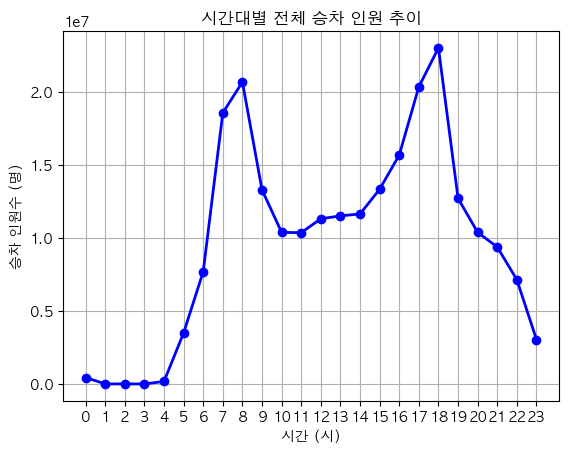

In [17]:
# (a) 시간별 승차 인원 추이
boarding_by_hour = recent_subway[recent_subway['type'] == '승차'].groupby('hour')['value'].sum()

plt.plot(boarding_by_hour.index, boarding_by_hour.values, marker='o', color='blue', linewidth=2)

plt.title('시간대별 전체 승차 인원 추이')
plt.xlabel('시간 (시)')
plt.ylabel('승차 인원수 (명)')

plt.xticks(range(24))
plt.grid(True)

plt.savefig('subway_hourly_boarding.png', bbox_inches='tight')

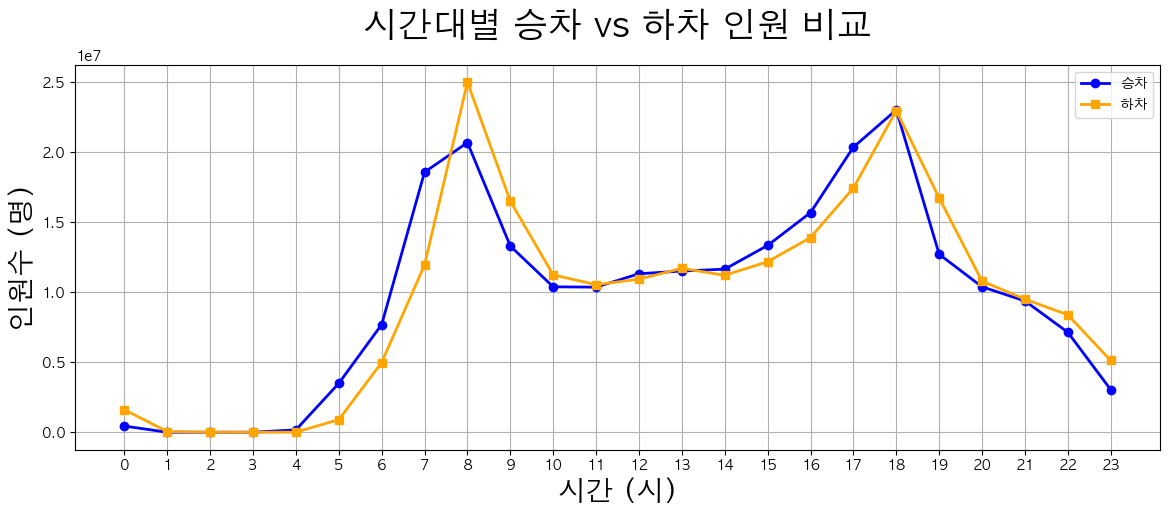

In [18]:
# (b) 승차 vs 하차 비교
boarding_by_hour = recent_subway[recent_subway['type'] == '승차'].groupby('hour')['value'].sum()
alighting_by_hour = recent_subway[recent_subway['type'] == '하차'].groupby('hour')['value'].sum()

plt.figure(figsize=(14,5))

plt.plot(boarding_by_hour.index, boarding_by_hour.values, marker='o', label='승차', color='blue', linewidth=2)
plt.plot(alighting_by_hour.index, alighting_by_hour.values, marker='s', label='하차', color='orange', linewidth=2)

plt.title('시간대별 승차 vs 하차 인원 비교',pad=20,fontsize=25)
plt.xlabel('시간 (시)',fontsize=20)
plt.ylabel('인원수 (명)',fontsize=20)
plt.xticks(range(24))
plt.legend()
plt.grid(True)

plt.savefig('fig00_time_compare.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

---
## Q7. 출퇴근 혼잡 가설 1차 검증 (2점)

**과제:**
- (a) 평일·주말 구분이 가능한 데이터인 경우 시간대별 패턴 비교. 안 되는 경우 (월별 합산 데이터인 경우) 시간대별 합산만 진행
  - 데이터 출처에 따라 일자별 시간대 데이터가 있을 수도, 월 합산만 있을 수도 있음. 본인 데이터에 맞춰 진행
- (b) 출퇴근 시간(7-9시 + 18-20시)의 총 인원이 전체 일평균(또는 월평균)의 몇 %를 차지하는가?
- (c) 결과를 보고 가설 1차 검증 (markdown):
  - 출퇴근 시간의 인원 비중이 압도적인가, 균등한가?
  - 가설(출퇴근 집중) 1차 지지 정도를 한 줄로 결론

In [19]:
# 가설 1차 검증
hourly_total = recent_subway.groupby('hour')['value'].sum()

commute_hours = [7, 8, 18, 19]
commute_total = hourly_total.loc[commute_hours].sum()

grand_total = hourly_total.sum()

commute_percentage = (commute_total / grand_total) * 100

print(f"출퇴근 시간대(7-9시, 18-20시) 총 이용객: {commute_total:,} 명")
print(f"한 달 전체 총 이용객: {grand_total:,} 명")
print(f"전체 이용객 중 출퇴근 시간대 비중: {commute_percentage:.2f}%")

출퇴근 시간대(7-9시, 18-20시) 총 이용객: 151,603,282 명
한 달 전체 총 이용객: 468,138,527 명
전체 이용객 중 출퇴근 시간대 비중: 32.38%


**결론:**
출퇴근 시간 인원 비중이 압도적으로 많음. 데이터의 분포가 균일하지않고 특정 시간대에 몰려 있는 것을 알 수 있음.

"출퇴근 시간의 혼잡이 특정 시간대에 집중되는가?"라는 가설은 이번 비중 분석과 시간대별 시각화 추이를 통해 매우 강력하게 지지됨을 확인.

---
## ✨ Q8. 자유 분석 — 팀의 독창적 발견 (3점)

**필수 과제:** 위 Q5-Q7에서 묻지 않은 새로운 분석 1가지를 본인 팀이 직접 설계하여 수행하세요.

**팀이 자유롭게 결정해야 할 것:**
- 어떤 분석을 할지 (분석 질문 정의)
- 어떤 도구를 쓸지 (groupby, pivot_table 등)
- 어떻게 시각화할지 (그림 종류, 색상 등)

**예시 (참고만 — 그대로 따르지 말고 팀이 새로운 질문을 던지세요):**
- 호선별 시간대 패턴 비교 (어느 호선이 가장 출퇴근형인가?)
- 환승역 vs 일반역의 패턴 차이 (환승역 정보가 있다면)
- 강남 3구 역 vs 강북 역의 패턴 비교
- 첫차/막차 시간대의 특이 패턴

**제출 항목:**
- 분석 질문 (markdown)
- 코드 (1-2 셀)
- 시각화 1개 (matplotlib 사용)
- 한 줄 해석

**우리 팀의 분석 질문:**
서울의 밤 문화 핫플레이스 중심지는 어디일까?

지하철 막차 탑승 인원에 따른 핫플 역을 알아보자

In [20]:
last_time = [0, 1, 2]
night_boarding = recent_subway[(recent_subway['hour'].isin(last_time)) & (recent_subway['type'] == '승차')]
night_top10 = night_boarding.groupby('station')['value'].sum().sort_values(ascending=False).head(10)

night_top10

station
홍대입구        15730
강남          12352
건대입구        10478
합정           9355
잠실(송파구청)     9328
사당           9167
종로3가         8137
서울역          7831
을지로3가        7358
신촌           7215
Name: value, dtype: int64

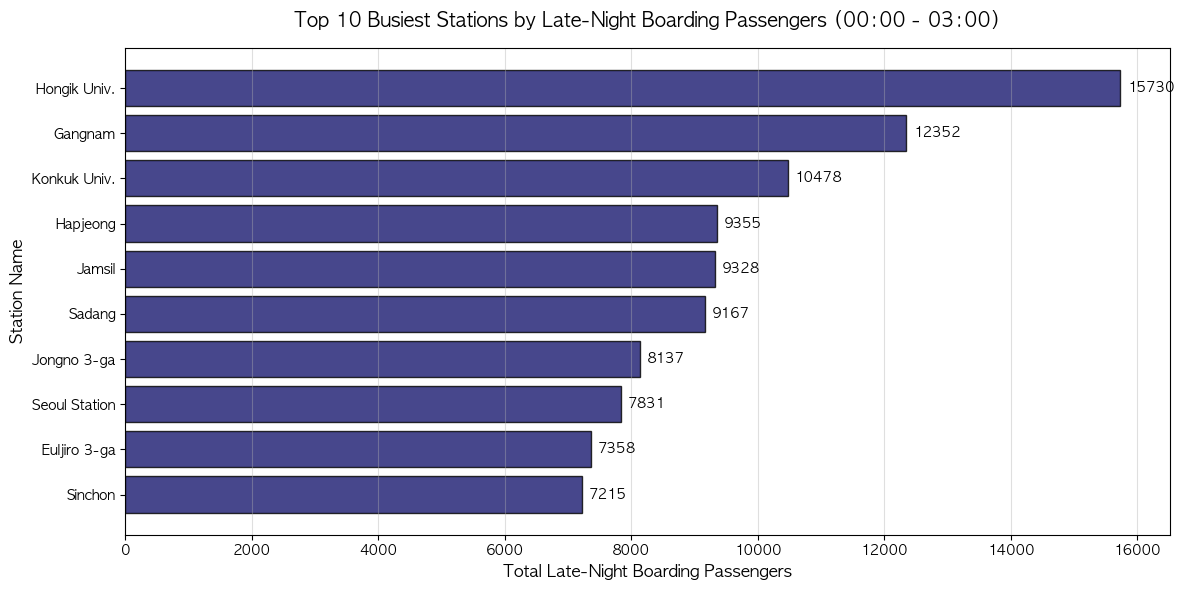

Hongik Univ.     15730
Gangnam          12352
Konkuk Univ.     10478
Hapjeong          9355
Jamsil            9328
Sadang            9167
Jongno 3-ga       8137
Seoul Station     7831
Euljiro 3-ga      7358
Sinchon           7215
Name: value, dtype: int64

In [21]:
import matplotlib.pyplot as plt

last_time = [0, 1, 2]
night_boarding = recent_subway[(recent_subway['hour'].isin(last_time)) & (recent_subway['type'] == '승차')]

night_top10 = night_boarding.groupby('station')['value'].sum().sort_values(ascending=False).head(10)

eng_station_names = {
    '홍대입구': 'Hongik Univ.', '강남': 'Gangnam', '잠실(송파구청)': 'Jamsil',   
    '서울역': 'Seoul Station', '건대입구': 'Konkuk Univ.', '종로3가': 'Jongno 3-ga',
    '사당': 'Sadang', '합정': 'Hapjeong', '고속터미널': 'Express Bus Terminal', 
    '혜화': 'Hyehwa', '을지로3가': 'Euljiro 3-ga', '신촌': 'Sinchon'
}
night_top10.index = [eng_station_names.get(name, name) for name in night_top10.index]

plt.figure(figsize=(12, 6))

bars = plt.barh(night_top10.index[::-1], night_top10.values[::-1], color='midnightblue', edgecolor='black', alpha=0.8)

plt.bar_label(bars, padding=5, fontweight='bold', fontsize=10)

plt.title('Top 10 Busiest Stations by Late-Night Boarding Passengers (00:00 - 03:00)', fontsize=14, pad=15)
plt.xlabel('Total Late-Night Boarding Passengers', fontsize=12)
plt.ylabel('Station Name', fontsize=12)
plt.grid(axis='x', linestyle='-', alpha=0.4)

plt.tight_layout()
plt.show()

night_top10

**해석:**
00시 이후 심야 승차 인원이 가장 몰리는 역들을 통해 홍대,강남,건대 등이 서울에서 밤늦은 시간까지 소비와 여가 활동이 가장 활발하게 일어나는 핫플 중심지들임을 알 수 있다.

---
## Q9. 데이터 저장 — Week 2 준비 (1점)

**과제:**
- 전처리·재구성 완료된 데이터프레임을 CSV 파일로 저장 (Week 2에서 다시 사용)
- 파일명: `subway_clean.csv`
- 한글이 포함되어 있으면 인코딩에 주의

**예상 결과:**
- 노트북과 같은 폴더에 `subway_clean.csv` 가 생성됨

In [24]:
# 데이터 저장
recent_subway.to_csv('subway_clean.csv', index=False, encoding='utf-8-sig')

---

## ✅ Week 1 체크리스트

- [ ] 팀 정보 표 작성 완료
- [ ] Q1: 데이터 로드 + 컬럼 구조 정리
- [ ] Q2: 결측치 점검 + 사용월 datetime 변환
- [ ] Q3: **wide → long 변환** (`pd.melt` + hour/type 추출)
- [ ] Q4: 시간대 카테고리 파생 변수
- [ ] Q5: 호선·역·승하차 비율 기본 통계
- [ ] Q6: 시간 패턴 그림 2개
- [ ] Q7: 출퇴근 혼잡 가설 1차 검증
- [ ] Q8: **자유 분석 1건** (팀의 독창적 질문)
- [ ] Q9: 전처리 데이터 저장

## 📋 Week 1 제출물
- 이 노트북 (실행된 결과 포함)
- `subway_clean.csv`

## 🔮 Week 2 미리보기
Week 2 노트북은 다음 주차 수업 시작 시점에 별도 배포됩니다. 큰 방향만 미리 알려드리면:
- 호선·역의 추가 정보 (마스터 데이터) 결합
- 혼잡 핫스팟 역 본격 식별
- 승차/하차 비대칭 분석
